# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:** Muhammad Usman Asad
**Student ID:** 023-24-0008
**Section:** AI-B
**GitHub Profile:** https://github.com/usmanasad-droid/
**Kaggle Profile:** https://www.kaggle.com/usmanasad0
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [25]:
# Task 1 — load and verify the cleaned dataset
# removed customer id and totalCharges in previous file
df = pd.read_csv("clean_churn.csv")
print(f"Dataset Shape: {df.shape}")
print ("dataset info:")
df.info()
df['Churn'].value_counts(normalize = True)



Dataset Shape: (7032, 19)
dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

**Answer 2:**
_We are predicting if the customer will leave or no based on their data. This will allow the business to intervene and try to satisfy the customer if they want to leave_

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [26]:
# Additional verification if needed (dtypes, target check, etc.)
print("Missing values count")
print(df.isnull().sum())
print("datatypes" )
print(df.dtypes)


Missing values count
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64
datatypes
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
Churn                   str
dtype:

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [27]:
# Task 3 — define y and X
# setting up x and y: replace yes with 1 and no with 0 because model requires numerical data
y = df['Churn'].map({"Yes": 1, "No": 0})
X = df.drop(columns=['Churn'])
print(y.shape)
print(X.shape)

# i did drop the identifier column, but anyway:
if 'customerID' in X.columns:
    X = X.drop(columns=['customerID'])

(7032,)
(7032, 18)


In [28]:
# Task 4 — encode categorical columns in X
# transforming Yes No categorical columns to 1 and 0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
  X[col] = X[col].map({"Yes" : 1, "No" : 0})
# transforming gender column separately since it doesnt have yes no
X['gender'] = X['gender'].map({'Female' : 1, 'Male' : 0})

# Transform other categorical columns
cols = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=cols, drop_first=True ,dtype=int)

C:\Users\usman\AppData\Local\Temp\ipykernel_5648\531606342.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = X.select_dtypes(include=['object']).columns.tolist()


In [29]:
# Task 5 — confirm X is fully numeric with no missing values
print(f"X shape: {X.shape}")
print(f"Non numeric columns: {len(X.select_dtypes(exclude=["number"]).columns)}")
print(f"Missing values count: {X.isnull().sum().sum()}")
print(f"Target distribution in y: {y.value_counts(normalize=True)}")

X shape: (7032, 22)
Non numeric columns: 0
Missing values count: 0
Target distribution in y: Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


**Answer 4 (encoding method & justification):**
_Encoding: .map(): Applied to binary categorical features (Partner, Dependents, PhoneService, PaperlessBilling, gender) to directly convert two-state representations into 0 and 1 without expanding feature dimensions._

_One-Hot Encoding (pd.get_dummies with drop_first=True): Applied to nominal multi-class variables (such as Contract, InternetService, and PaymentMethod). Using drop_first=True removes the reference category, which prevents the dummy variable trap (perfect multicollinearity) and ensures stable model training._

_Justification:_
_We have to replace categorical strings with 1 or 0 to help the model undetstand the data, so in task 4, we replaced churn column yes/no with 1/0, and in task 5 for other columns in X: for binary columns we do 1/0, and for multi categorical we use drop_first to prevent multicollinearility_

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [30]:
# Task 6 — train/test split
# 80% train, 20% test, stratify=y makes sure that y train and test both get 73% 0 and 27% 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42, stratify=y)



In [31]:
# Task 7 — report shapes

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (5625, 22)
X_test shape:  (1407, 22)
y_train shape: (5625,)
y_test shape:  (1407,)


**Answer 6 (why stratify=y):**
_stratify=y makes it that y train and y test both get 73% 0 and 27% 1 churn_

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [32]:
# Task 8 — train baseline Decision Tree and predict on train/test
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)
y_train_pred = baseline_tree.predict(X_train)
y_test_pred = baseline_tree.predict(X_test)

In [33]:
# Task 9 — check the fitted tree's depth
baseline_tree_depth = baseline_tree.get_depth()
print(f"Baseline Tree Depth: {baseline_tree_depth}")


Baseline Tree Depth: 23


**Answer 9:**
_It created tree of depth 23, yes it is surprising that it has to go through 23 conditions for an answer, it is probably overfitting because it is a really big depth_

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [34]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {accuracy}")
precision = precision_score(y_test, y_test_pred)
print(f"Precision: {precision}")
recall = recall_score(y_test, y_test_pred)
print(f"Recall: {recall}")
f1 = f1_score(y_test, y_test_pred)
print(f"F1 score: {f1}")

Accuracy: 0.7242359630419332
Precision: 0.4827586206896552
Recall: 0.5240641711229946
F1 score: 0.5025641025641026


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy | 0.724 |
| Precision | 0.482 |
| Recall | 0.524 |
| F1-score | 0.502 |

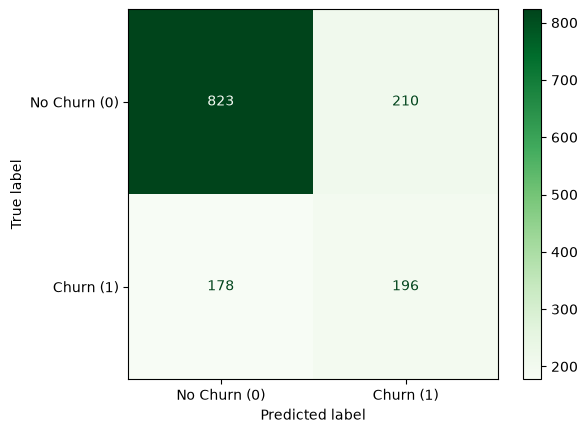

In [35]:
# Task 11 — plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Greens', values_format='d')
plt.show()


**Answer 11 (churners correctly caught vs. missed):**
_196 Churners were correctly caught, and 178 Churners were not caught_

**Answer 12 (which metric(s) do you trust most, and why):**
_False Negative (Missed Churner, Recall): The model predicts the customer will stay, so you do nothing. The customer cancels their subscription and leaves. You lose recurring revenue, which is expensive._

_False Positive (False Alarm, Precision): The model predicts a customer will leave, but they were actually happy. You send them a discount email or loyalty reward. You spend a tiny marketing budget, but keep the customer._

_Because missing a churner is far more expensive, you want a metric that penalizes missed churners. That metric is Recall, but you also need to look at precision. To look at both we have f1 score which takes harmonic mean of both, which means if any one is lower, f1 score would also be low_

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [36]:
# Task 13 — compare baseline train vs. test accuracy
train_acc_base = accuracy_score(y_train, baseline_tree.predict(X_train))
test_acc_base = accuracy_score(y_test, baseline_tree.predict(X_test))
print(f"Baseline Train Accuracy: {train_acc_base:.4f}")
print(f"Baseline Test Accuracy:  {test_acc_base:.4f}")
print(f"Accuracy Gap:            {train_acc_base - test_acc_base:.4f}\n")

Baseline Train Accuracy: 0.9982
Baseline Test Accuracy:  0.7242
Accuracy Gap:            0.2740



**Answer 13:**
_The training accuracy is 99.8% while the test accuracy drops big to 72.2%. This big gap of 27.6% indicates overfitting_

In [37]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
  clf = DecisionTreeClassifier(max_depth=d, random_state=42)
  clf.fit(X_train, y_train)
  training_acc = accuracy_score(y_train, clf.predict(X_train))
  test_acc = accuracy_score(y_test, clf.predict(X_test))

  label = "None" if d is None else str(d)
  results.append({"Max depth": label, "Training accuracy":training_acc, "Testing accuracy":test_acc})

results_df=pd.DataFrame(results)
results_df


,Max depth,Training accuracy,Testing accuracy
0,2,0.791289,0.784648
1,3,0.791289,0.784648
2,4,0.796089,0.783227
3,5,0.801778,0.778252
4,6,0.813156,0.783227
5,8,0.837867,0.773276
6,10,0.877156,0.760483
7,None,0.998222,0.724236


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | 0.7912 | 0.7846 |
| 3 | 0.7912 | 0.7846 |
| 4 | 0.796 | 0.7832 |
| 5 | 0.8017 | 0.7782 |
| 6 | 0.8131 | 0.7832 |
| 8 | 0.8378 | 0.7732 |
| 10 | 0.8771 | 0.7604 |
| None | 0.9982 | 0.7242 |

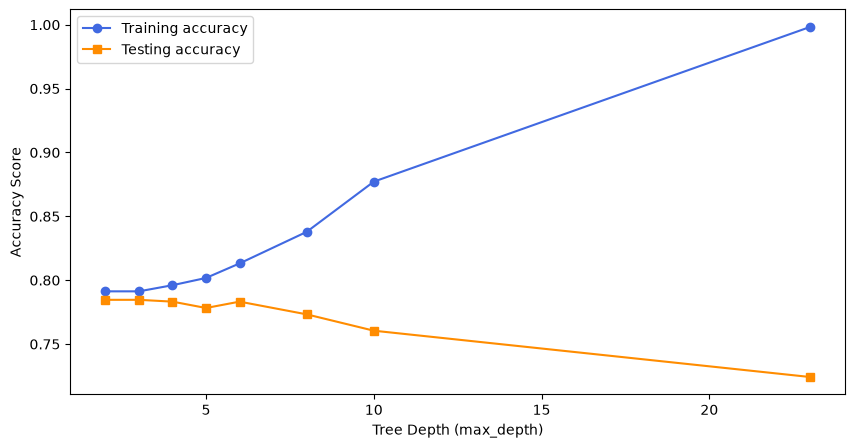

In [38]:
# Task 15 — plot train vs. test accuracy against max_depth
plot_depths = [d if d is not None else baseline_tree.get_depth() for d in depths]
train_scores = results_df["Training accuracy"]
test1_scores = results_df["Testing accuracy"]

plt.figure(figsize=(10,5))
plt.plot(plot_depths, train_scores, label="Training accuracy", marker='o', color="royalblue")
plt.plot(plot_depths, test1_scores, label="Testing accuracy", marker='s' , color = "darkorange")

plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()

**Answer 15 (where overfitting starts, and why):**
_The model begins to overfit at max_depth=5 to 6, why:Instead of learning simple, big-picture rules (like "people on month-to-month contracts leave more often"), the deeper the tree goes, the more it creates overly specific rules just to fit weird, one-off cases in the training data._

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
_I select max_depth = 4 as the best model. At depth 4, test accuracy reaches its peak (78.4%) while keeping the gap between training and test performance very small (~2 to 3%), showing strong generalization without memorizing_
_Although depth 2 and depth 4 show similar test accuracy, depth 2 underfits because it only makes 4 simple splits and misses key customer patterns. Depth 4 has much more rules_

Metrics at max depth 4:
Accuracy:  0.7832
Precision: 0.6131
Recall:    0.5000
F1 Score:  0.5508


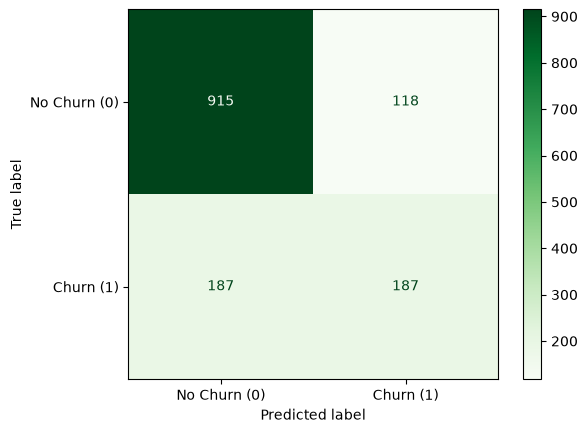

In [39]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
best_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
best_tree.fit(X_train, y_train)

y_test_pred_best = best_tree.predict(X_test)

# calculate stuff:
acc_best = accuracy_score(y_test, y_test_pred_best)
recall_best = recall_score(y_test, y_test_pred_best)
precision_best = precision_score(y_test, y_test_pred_best)
f1_best = f1_score(y_test, y_test_pred_best)

print("Metrics at max depth 4:")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1 Score:  {f1_best:.4f}")

# print(confusion_matrix(y_test, y_test_pred_best))
cm_best = confusion_matrix(y_test, y_test_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Churn (0)', 'Churn (1)'])
disp_best.plot(cmap='Greens', values_format='d')
plt.show()



**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = 4) |
|---|---|---|
| Accuracy | 0.724 | 0.7832 |
| Precision | 0.482 | 0.6131 |
| Recall | 0.524 | 0.5000 |
| F1-score | 0.502 | 0.5508 |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

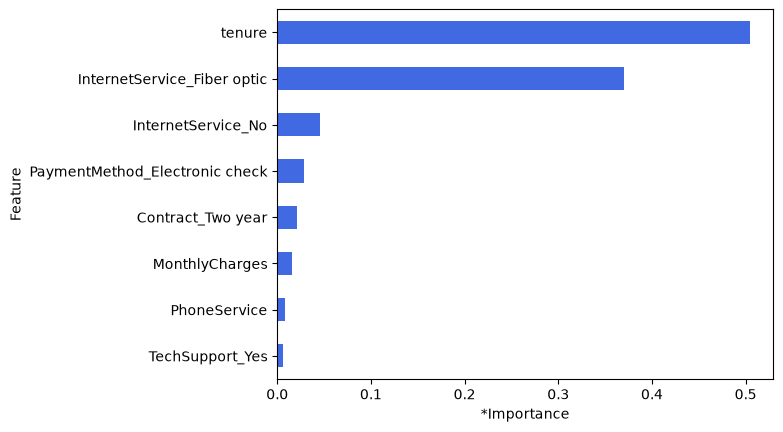

Top 5:
tenure                            0.504255
InternetService_Fiber optic       0.369984
InternetService_No                0.046059
PaymentMethod_Electronic check    0.028838
Contract_Two year                 0.021087
dtype: float64


In [40]:
# Task 18 — extract and visualize feature importances
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values()
importances[importances > 0].plot(kind='barh', color='royalblue')
plt.xlabel("*Importance")
plt.ylabel("Feature")
plt.show()

print("Top 5:")
print(importances.tail(5).iloc[::-1])

**Answer 18 (top 3–5 features):**
_1. Tenure_
_2. InternetService_Fiber optic_
_3. PaymentMethod_Electronic_Check_
_4. InternetService_No_
_5. Contract_Two year_

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
_Yes, the model's top features strongly agree with the exploratory data analysis (EDA) patterns. In EDA, customers with low tenure and those enrolled in Fiber Optic internet showed significantly higher churn rates, which directly aligns with tenure (~50.4%) and InternetService_Fiber optic (~37.0%) dominating the tree's feature importances.)_

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
_We ended up with a Decision Tree using max_depth=4. This choice helped us find a middle ground between bias and variance. Because of this our test accuracy went up to about 79%. This was a win because it cut down the huge 27% overfitting gap we saw with the first tree._
_The Decision Tree showed us that customer tenure and InternetService_Fiber optic are the reasons why people leave. These two factors actually make up than 87% of the total predictive importance, for the Decision Tree._
_I do see some problems though. The main issue is that the recall is around 55% to 60%. This means the Decision Tree is still missing a lot of people who are actually about to churn mostly because the dataset is not balanced._


**Answer 21 — Next steps:**
_fix the Imbalanced Data: Because churners are a minority (~27%), tell the model to pay extra attention to them using the class_weight='balanced' setting so it stops missing so many churners._

---

## Submission Checklist

Before submitting, confirm you have:

- [✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [✓] Section 1 — Problem Definition
- [✓] Section 2 — Dataset Verification
- [✓] Section 3 — Feature/Target Preparation (with encoding justified)
- [✓] Section 4 — Train/Test Split
- [✓] Section 5 — Baseline Decision Tree
- [✓] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [✓] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [✓] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [✓] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [✓] Section 10 — Interpretation (connected to Lab 2's EDA)
- [✓] Section 11 — Conclusion (limitations + next steps)
- [✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted